# HOUSE PRICES - ADVANCED REGRESSION TECHNIQUES

## 2. Data Understanding
Phần này thực hiện khám phá và tìm hiểu dữ liệu (EDA), bao gồm kiểm tra cấu trúc dữ liệu, kiểu dữ liệu, dữ liệu thiếu, phân phối của biến mục tiêu SalePrice và mối tương quan giữa các đặc trưng.

In [1]:
# CELL 1: IMPORT THƯ VIỆN

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Import thư viện thành công!")

Import thư viện thành công!


In [2]:
# CELL 2: LOAD DATA

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (1460, 81)
Test Shape: (1459, 80)


In [3]:
# CELL 3: KIỂM TRA THÔNG TIN TẬP TRAIN

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
# CELL 4: KIỂM TRA THÔNG TIN TẬP TEST

test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

In [5]:
# CELL 5: KIỂM TRA GIÁ TRỊ THIẾU TRONG TRAIN

train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

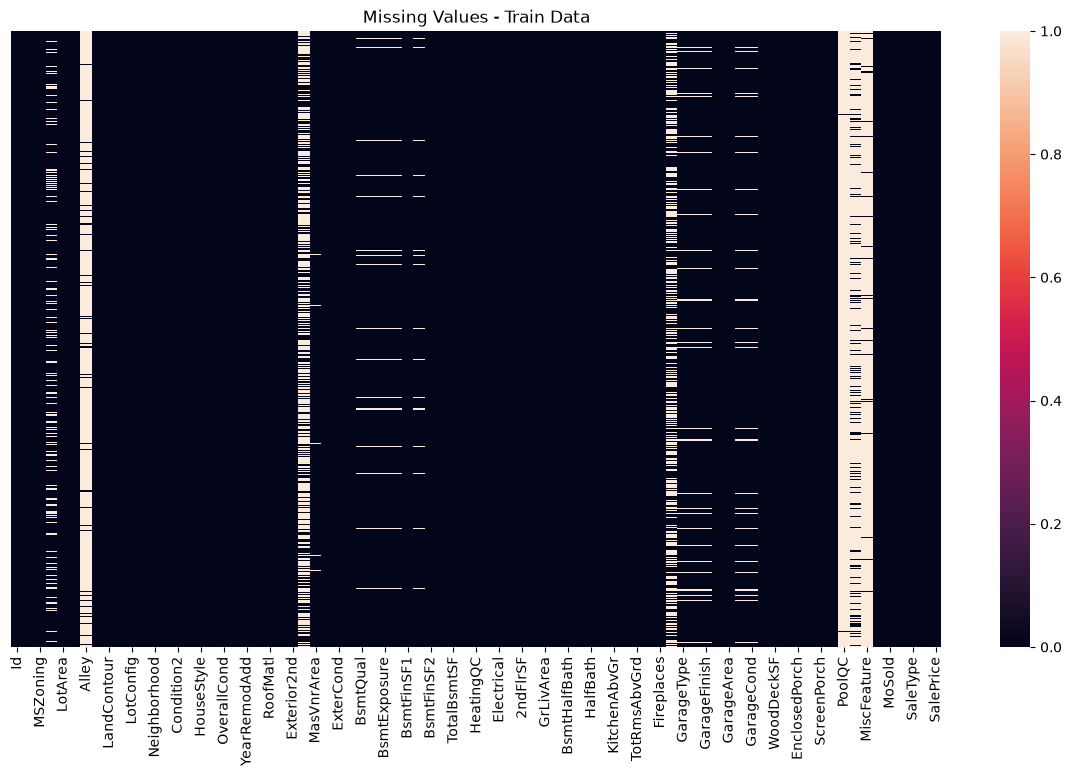

In [6]:
# CELL 6: HEATMAP GIÁ TRỊ THIẾU CỦA TRAIN

plt.figure(figsize=(15, 8))
sns.heatmap(train.isnull(), yticklabels=False, cbar=True)

plt.title("Missing Values - Train Data")
plt.show()

In [7]:
# CELL 7: KIỂM TRA GIÁ TRỊ THIẾU TRONG TEST

test.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

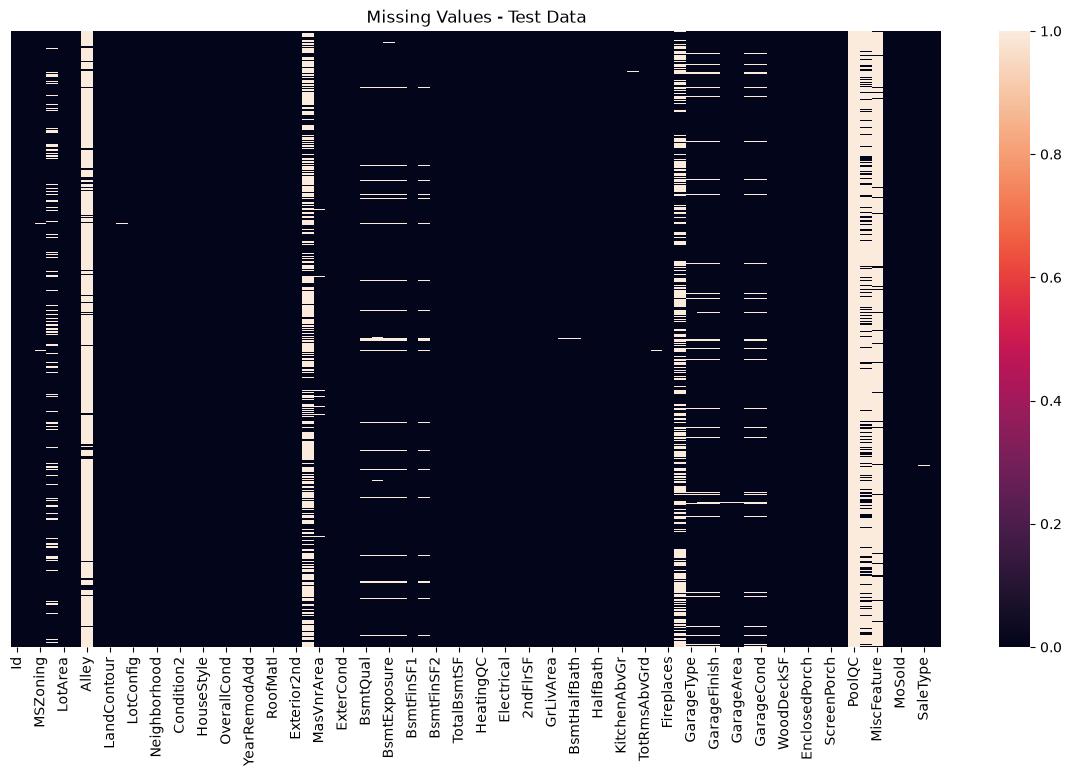

In [8]:
# CELL 8: HEATMAP GIÁ TRỊ THIẾU CỦA TEST

plt.figure(figsize=(15, 8))
sns.heatmap(test.isnull(), yticklabels=False, cbar=True)

plt.title("Missing Values - Test Data")
plt.show()

## Handling NULL data

Qua quá trình kiểm tra dữ liệu thiếu, có thể thấy các thuộc tính `Alley`, `PoolQC`, `Fence` và `MiscFeature` có tỷ lệ giá trị thiếu lớn (trên 70%) trong cả tập train và test. Vì vậy, các thuộc tính này sẽ được loại bỏ.

Ngoài ra, cột `Id` cũng được loại bỏ vì đây chỉ là mã định danh của từng mẫu dữ liệu.

Đối với các thuộc tính phân loại (categorical), giá trị thiếu sẽ được thay thế bằng giá trị xuất hiện nhiều nhất (mode).

Đối với các thuộc tính không phải phân loại (non-categorical), giá trị thiếu sẽ được thay thế bằng giá trị trung bình (mean).

In [ ]:
# CELL 9: HANDLING NULL DATA - TRAIN DATA

cat_col_train = [
    'FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType',
    'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
    'GarageQual', 'GarageCond'
]

ncat_col_train = [
    'LotFrontage', 'GarageYrBlt', 'MasVnrArea'
]

# Điền giá trị thiếu của cột categorical bằng mode
for i in cat_col_train:
    train[i] = train[i].fillna(train[i].mode()[0])

# Điền giá trị thiếu của cột numerical bằng mean
for j in ncat_col_train:
    train[j] = train[j].fillna(train[j].mean())

In [9]:
# CELL 10: HANDLING NULL DATA - TEST DATA

cat_col_test = [
    'FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType',
    'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'MSZoning', 'Utilities',
    'Exterior1st', 'Exterior2nd', 'KitchenQual',
    'Functional', 'SaleType'
]

ncat_col_test = [
    'LotFrontage', 'GarageYrBlt', 'MasVnrArea',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
    'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath',
    'GarageCars', 'GarageArea'
]

# Điền giá trị thiếu của cột categorical bằng mode
for i in cat_col_test:
    test[i] = test[i].fillna(test[i].mode()[0])

# Điền giá trị thiếu của cột numerical bằng mean
for j in ncat_col_test:
    test[j] = test[j].fillna(test[j].mean())

In [10]:
to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']

In [11]:
# CELL 11: DROP COLUMNS

to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']

for k in to_drop:
    train.drop(k, axis=1, inplace=True)
    test.drop(k, axis=1, inplace=True)

<Axes: >

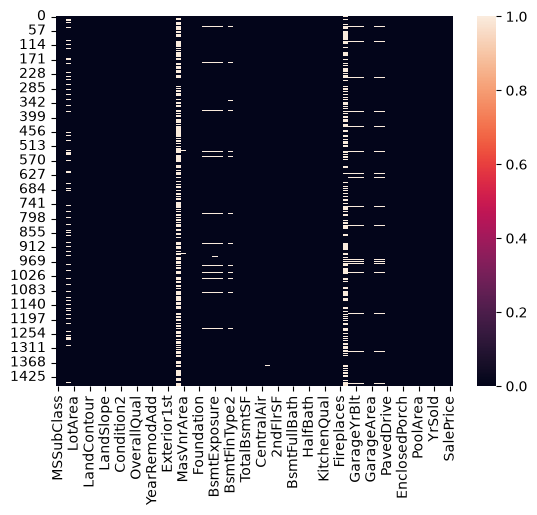

In [12]:
sns.heatmap(train.isnull())


<Axes: >

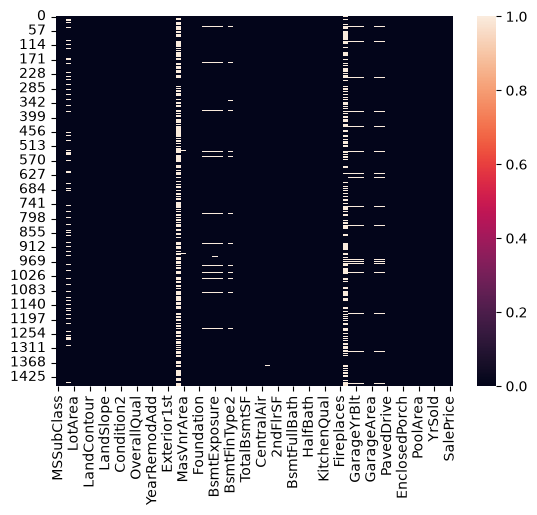

In [14]:
# CELL 12: KIỂM TRA LẠI NULL VALUES - TRAIN DATA

sns.heatmap(train.isnull())

<Axes: >

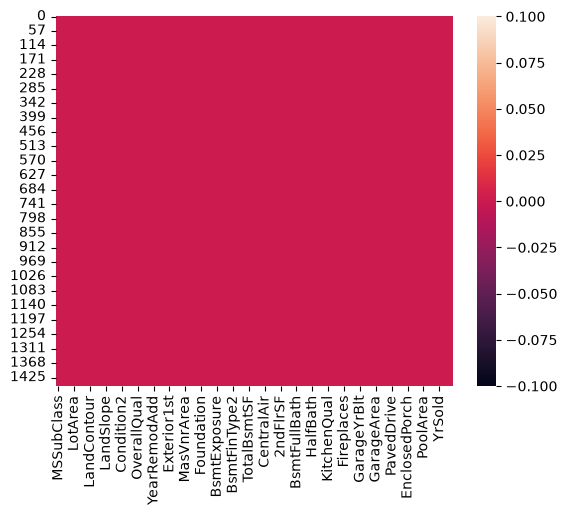

In [13]:
sns.heatmap(test.isnull())

<Axes: >

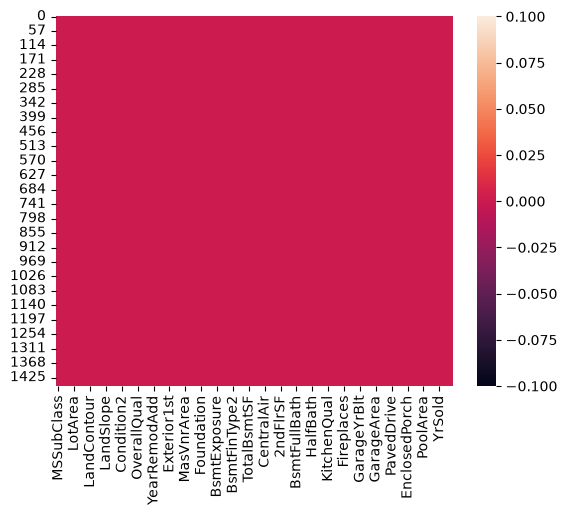

In [15]:
# CELL 13: KIỂM TRA LẠI NULL VALUES - TEST DATA

sns.heatmap(test.isnull())

In [17]:
# CELL 14: KIỂM TRA LẠI KÍCH THƯỚC DỮ LIỆU

print("Train Shape:", train.shape)
print("Test Shape :", test.shape)

Train Shape: (1460, 76)
Test Shape : (1459, 75)


In [16]:
# CELL 15: THỐNG KÊ BIẾN MỤC TIÊU SALEPRICE

print(train['SalePrice'].describe())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


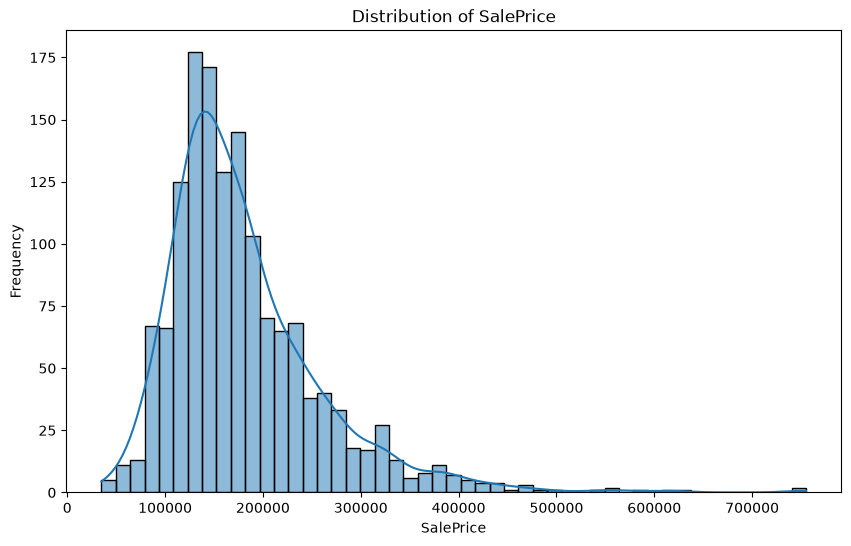

In [18]:
# CELL 16: PHÂN PHỐI GIÁ NHÀ - SALEPRICE

plt.figure(figsize=(10, 6))

sns.histplot(train['SalePrice'], kde=True)

plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')

plt.show()

In [19]:
# CELL 17: KIỂM TRA ĐỘ LỆCH CỦA SALEPRICE

print("Skewness:", train['SalePrice'].skew())
print("Kurtosis:", train['SalePrice'].kurt())

Skewness: 1.8828757597682129
Kurtosis: 6.536281860064529


In [20]:
# CELL 18: PHÂN TÍCH TƯƠNG QUAN VỚI SALEPRICE

numeric_data = train.select_dtypes(include=[np.number])

correlation = numeric_data.corr()

saleprice_corr = correlation['SalePrice'].sort_values(ascending=False)

print(saleprice_corr)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


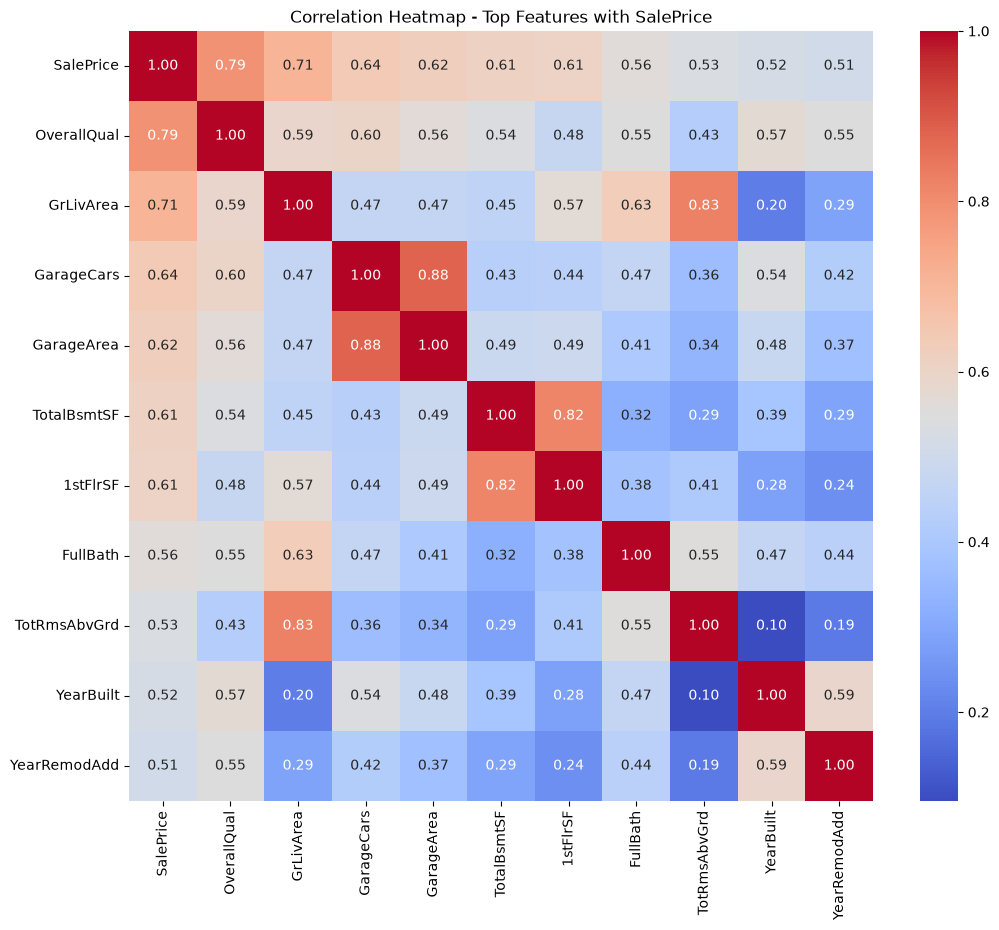

In [21]:
# CELL 19: HEATMAP TƯƠNG QUAN CÁC ĐẶC TRƯNG QUAN TRỌNG

top_features = saleprice_corr.head(11).index

plt.figure(figsize=(12, 10))

sns.heatmap(
    train[top_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap - Top Features with SalePrice")
plt.show()

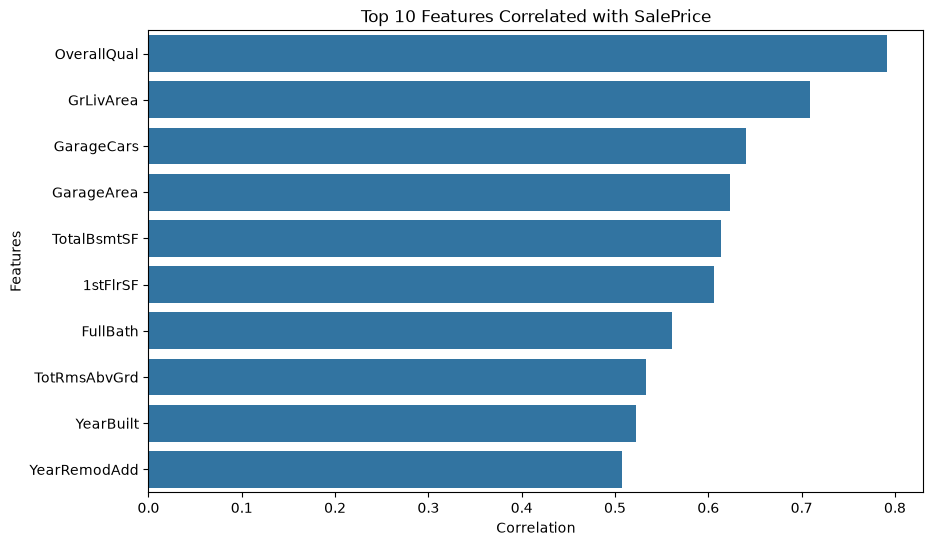

In [22]:
# CELL 20: TOP 10 FEATURES CORRELATED WITH SALEPRICE

top_corr = saleprice_corr.drop('SalePrice').head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top 10 Features Correlated with SalePrice")
plt.xlabel("Correlation")
plt.ylabel("Features")

plt.show()